
\#Online food delivery analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("//content/Cleaned_food_delivery_data.csv")

In [ ]:
pd.set_option("display.max_column",None)

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,0
Customer_Gender,0
City,0
Area,0
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,0
Order_Date,0


In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_performance_category,Age_Group
0,ORD000001,CUST6948,19.0,Male,unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,1197.0,100.0,1097.0,UPI,Delivered,Not_Applicable,DP563,5.0,4.4,Weekend,True,0.13,slow,Younger_Adult
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,Not_Applicable,DP369,5.0,4.7,Weekday,True,0.48,Fast,Adult
2,ORD000003,CUST1765,39.0,Male,Delhi,unknown,RES723,Restaurant_244,Arabian,2024-12-08,207.0,9.97,757.0,20.0,737.0,Wallet,Delivered,Not_Applicable,DP580,4.0,4.9,Weekend,True,0.08,slow,Adult
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,1197.0,100.0,1097.0,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,False,0.04,neutral,Adult
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.0,20.0,352.0,Card,Delivered,Not_Applicable,DP728,2.0,4.4,Weekend,False,0.12,Fast,Senior


In [ ]:
num_column = df.select_dtypes(include ="number").columns.tolist()
num_column

['Customer_Age',
 'Delivery_Time_Min',
 'Distance_km',
 'Order_Value',
 'Discount_Applied',
 'Final_Amount',
 'Delivery_Rating',
 'Restaurant_Rating',
 'Profit_Margin']

In [ ]:
corr_info =df[num_column].corr()
corr_info

,Customer_Age,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Delivery_Rating,Restaurant_Rating,Profit_Margin
Customer_Age,1.000000,-0.010272,-0.001595,-0.002048,0.001917,-0.002189,-0.001685,0.001574,0.001296
Delivery_Time_Min,-0.010272,1.000000,0.002161,0.002353,-0.001032,0.002444,0.003888,0.003126,-0.001058
Distance_km,-0.001595,0.002161,1.000000,0.000990,0.002646,0.000781,0.002348,0.003243,0.003064
Order_Value,-0.002048,0.002353,0.000990,1.000000,0.003023,0.997323,0.001048,-0.003956,-0.002724
Discount_Applied,0.001917,-0.001032,0.002646,0.003023,1.000000,-0.069896,0.002199,0.003421,0.004464
Final_Amount,-0.002189,0.002444,0.000781,0.997323,-0.069896,1.000000,0.000887,-0.004198,-0.003053
Delivery_Rating,-0.001685,0.003888,0.002348,0.001048,0.002199,0.000887,1.000000,0.004137,-0.000207
Restaurant_Rating,0.001574,0.003126,0.003243,-0.003956,0.003421,-0.004198,0.004137,1.000000,-0.000741
Profit_Margin,0.001296,-0.001058,0.003064,-0.002724,0.004464,-0.003053,-0.000207,-0.000741,1.000000


<Axes: >

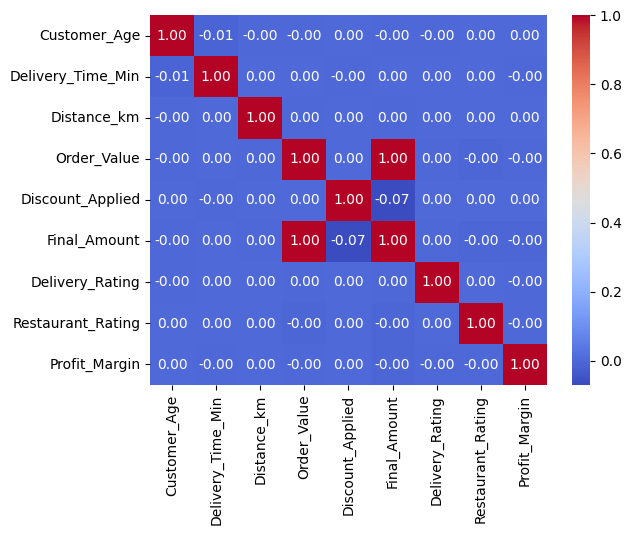

In [ ]:
sns.heatmap(corr_info,annot = True,fmt='.2f',cmap = "coolwarm")

#EDA

##1. Top 10 spending customer

In [ ]:
top_spending_customer = (df.groupby("Customer_ID")["Final_Amount"].sum().sort_values(ascending=False)).head(10)
top_spending_customer

,Final_Amount
Customer_ID,
CUST5267,51677.0
CUST1606,50971.0
CUST6706,47239.0
CUST6252,45825.0
CUST5534,45068.0
CUST1239,44733.0
CUST4431,44335.0
CUST6457,44201.0
CUST1968,44181.0


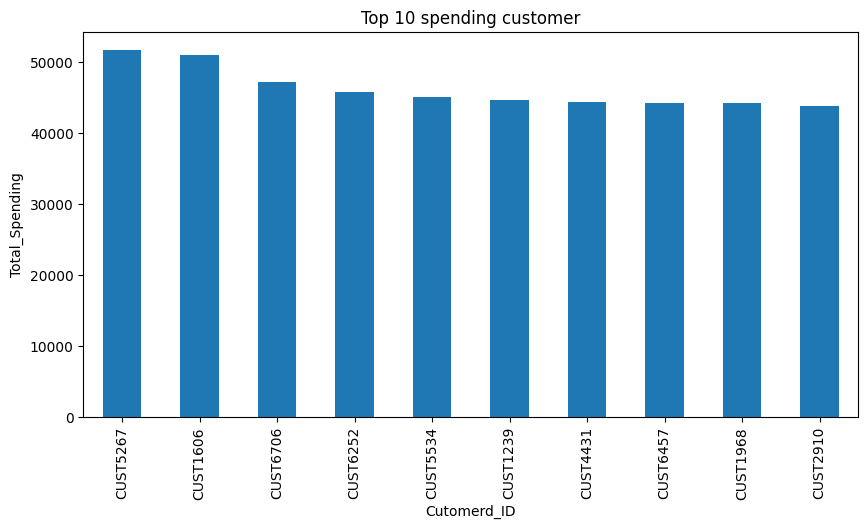

In [ ]:
plt.figure(figsize=(10,5))
top_spending_customer.plot(kind="bar")
plt.title("Top 10 spending customer")
plt.xlabel("Cutomerd_ID")
plt.ylabel("Total_Spending")
plt.show()

Insights:
A few customers contribute significantly to total revenue compare to other customers

2. Analyze age group vs order value

In [ ]:
age_vs_order_value = df.groupby("Age_Group")["Order_Value"].sum()
age_vs_order_value

,Order_Value
Age_Group,
Adult,129839205.0
Senior,20322759.0
Younger_Adult,26735783.0


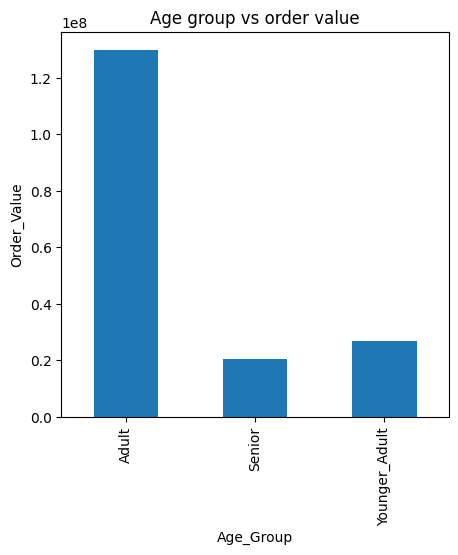

In [ ]:
plt.figure(figsize=(5,5))
age_vs_order_value.plot(kind="bar")
plt.title("Age group vs order value")
plt.xlabel("Age_Group")
plt.ylabel("Order_Value")
plt.show()

insights:
most revenue comes by adult compare to senior and younger_adult

3. Weekend vs weekday order patterns

In [ ]:
df.head(5)

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_performance_category,Age_Group
0,ORD000001,CUST6948,19.0,Male,unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,1197.0,100.0,1097.0,UPI,Delivered,Not_Applicable,DP563,5.0,4.4,Weekend,True,0.13,slow,Younger_Adult
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,Not_Applicable,DP369,5.0,4.7,Weekday,True,0.48,Fast,Adult
2,ORD000003,CUST1765,39.0,Male,Delhi,unknown,RES723,Restaurant_244,Arabian,2024-12-08,207.0,9.97,757.0,20.0,737.0,Wallet,Delivered,Not_Applicable,DP580,4.0,4.9,Weekend,True,0.08,slow,Adult
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,1197.0,100.0,1097.0,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,False,0.04,neutral,Adult
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.0,20.0,352.0,Card,Delivered,Not_Applicable,DP728,2.0,4.4,Weekend,False,0.12,Fast,Senior


In [ ]:
order_pattern = df["Order_Day"].value_counts()
order_pattern

,count
Order_Day,
Weekday,70618
Weekend,28368


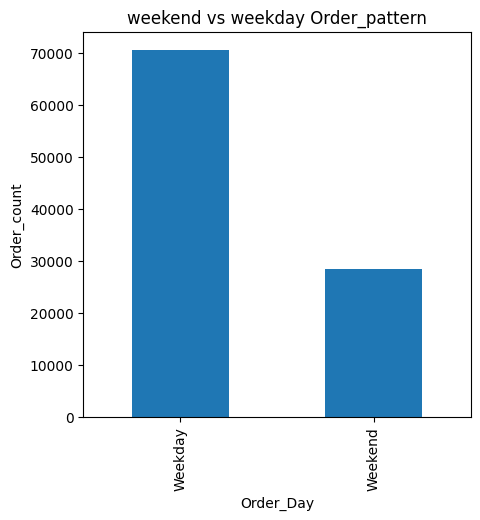

In [ ]:
plt.figure(figsize=(5,5))
order_pattern.plot(kind="bar")
plt.title("weekend vs weekday Order_pattern")
plt.xlabel("Order_Day")
plt.ylabel("Order_count")
plt.show()

insights:
 Most orders happen on weekdays 70,618 orders, compared with 28,368 on weekends.

4.monthly revenue

In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
month = df["Order_Date"].dt.to_period("M")
month

,Order_Date
0,2024-10
1,2024-08
2,2024-12
3,2024-10
4,2024-02
...,...
98981,2024-04
98982,2024-06
98983,2024-04
98984,2024-02


In [ ]:
monthly_revenue = df.groupby(month)["Final_Amount"].sum()
monthly_revenue

,Final_Amount
Order_Date,
2024-01,14416252.0
2024-02,13337626.0
2024-03,14114118.0
2024-04,13706742.0
2024-05,14142429.0
2024-06,13896071.0
2024-07,14581373.0
2024-08,13986979.0
2024-09,14029400.0


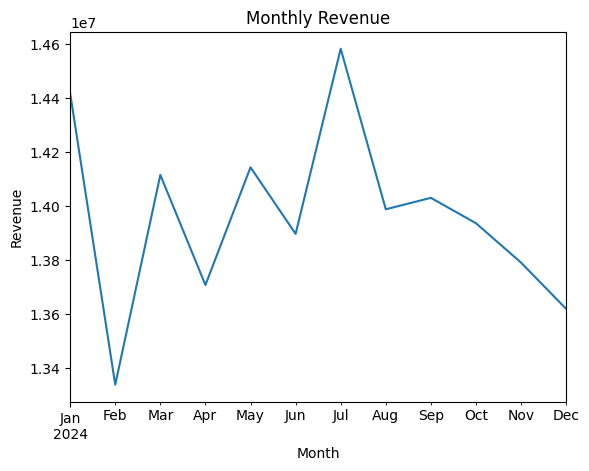

In [ ]:
monthly_revenue.plot(kind="line")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

insights:
july have the highest revenue of (14581373) and february has the lowest (13337626)

5.Impact of Discounts on Profit

In [ ]:
df["Price_Reduction"] = df["Order_Value"] - df["Final_Amount"]
impact = df.groupby("Discount_Applied")["Price_Reduction"].mean()
print(impact)


Discount_Applied
0.0        0.000000
20.0      20.000000
50.0      50.000000
100.0    100.000000
300.0    296.413267
Name: Price_Reduction, dtype: float64


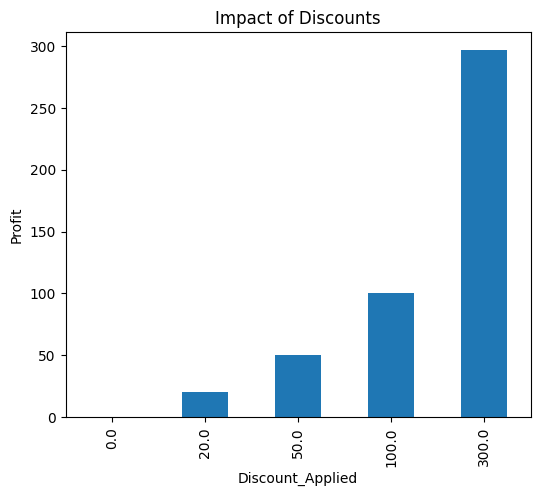

In [ ]:
  plt.figure(figsize=(6,5))
impact.plot(kind="bar")
plt.title("Impact of Discounts")
plt.xlabel("Discount_Applied")
plt.ylabel("Profit")
plt.show()

insights : Higher discounts directly increase the price reduction.

In [ ]:
df.head(5)

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_performance_category,Age_Group,Price_Reduction
0,ORD000001,CUST6948,19.0,Male,unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,1197.0,100.0,1097.0,UPI,Delivered,Not_Applicable,DP563,5.0,4.4,Weekend,True,0.13,slow,Younger_Adult,100.0
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,Not_Applicable,DP369,5.0,4.7,Weekday,True,0.48,Fast,Adult,20.0
2,ORD000003,CUST1765,39.0,Male,Delhi,unknown,RES723,Restaurant_244,Arabian,2024-12-08,207.0,9.97,757.0,20.0,737.0,Wallet,Delivered,Not_Applicable,DP580,4.0,4.9,Weekend,True,0.08,slow,Adult,20.0
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,1197.0,100.0,1097.0,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,False,0.04,neutral,Adult,100.0
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.0,20.0,352.0,Card,Delivered,Not_Applicable,DP728,2.0,4.4,Weekend,False,0.12,Fast,Senior,20.0


6. High-revenue cities and cuisines


In [ ]:
df["Cuisine_Type"].value_counts()

,count
Cuisine_Type,
Indian,22148
Arabian,19286
Chinese,19219
Mexican,19217
Italian,19116


In [ ]:
city_cuisine_revenue = df.groupby(["City","Cuisine_Type"])["Final_Amount"].sum().reset_index()
city_cuisine_revenue

,City,Cuisine_Type,Final_Amount
0,Bangalore,Arabian,5331091.0
1,Bangalore,Chinese,5447829.0
2,Bangalore,Indian,6545362.0
3,Bangalore,Italian,5320829.0
4,Bangalore,Mexican,5597465.0
5,Chennai,Arabian,5266690.0
6,Chennai,Chinese,5442188.0
7,Chennai,Indian,6311666.0
8,Chennai,Italian,5309661.0
9,Chennai,Mexican,5400582.0


In [ ]:
city_amount = df[df["City"] != "unknown"].groupby("City")["Final_Amount"].sum()
city_amount

,Final_Amount
City,
Bangalore,28242576.0
Chennai,27730787.0
Delhi,27816219.0
Hyderabad,28130193.0
Mumbai,27589781.0


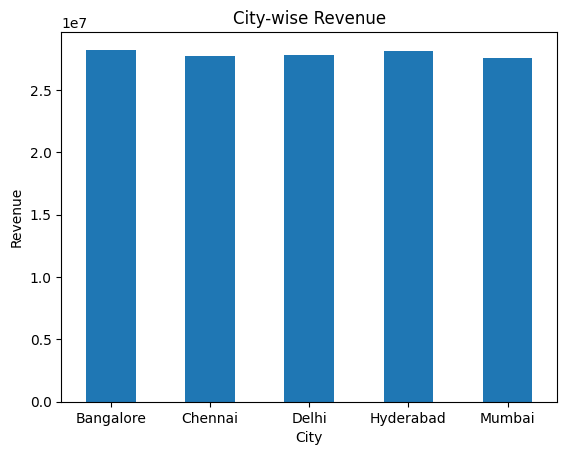

In [ ]:
city_amount.plot(kind="bar")
plt.title("City-wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation = 0)
plt.show()

In [ ]:
cusine_amount = df.groupby("Cuisine_Type")["Final_Amount"].sum()
cusine_amount

,Final_Amount
Cuisine_Type,
Arabian,32388188.0
Chinese,32577775.0
Indian,37696852.0
Italian,32161846.0
Mexican,32729747.0


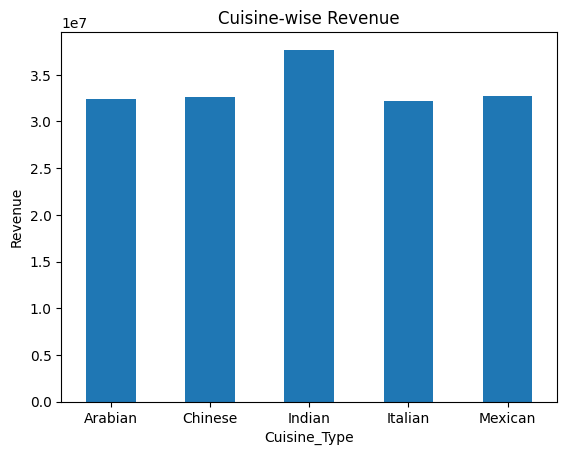

In [ ]:
cusine_amount.plot(kind="bar")
plt.title("Cuisine-wise Revenue")
plt.xlabel("Cuisine_Type")
plt.ylabel("Revenue")
plt.xticks(rotation = 0)
plt.show()

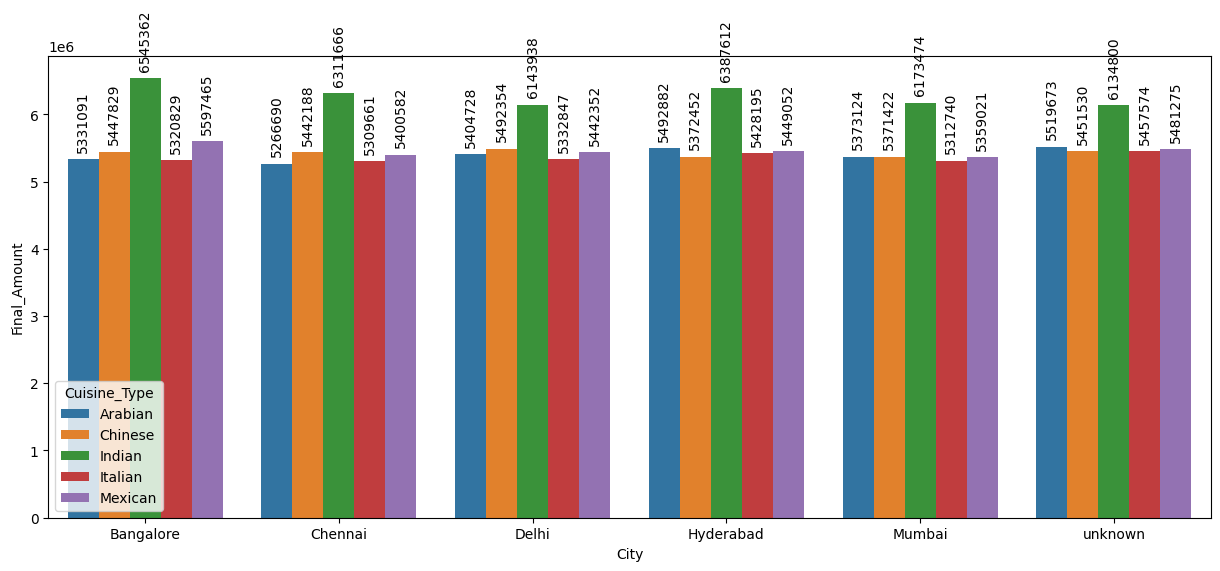

In [ ]:
plt.figure(figsize=(15,6))
ax = sns.barplot(data = city_cuisine_revenue,x="City",y="Final_Amount",hue="Cuisine_Type")
for container in ax.containers:
    ax.bar_label(container,fmt='%d',rotation =90,padding = 5)


Insights :
Bangalore has the highest city revenue and Indian cuisine generates the highest revenue.

7. Average delivery time by city


In [ ]:
avg_time = df.groupby("City")["Delivery_Time_Min"].mean()
avg_time

,Delivery_Time_Min
City,
Bangalore,124.341402
Chennai,124.584049
Delhi,124.906604
Hyderabad,125.045234
Mumbai,126.039458
unknown,125.051957


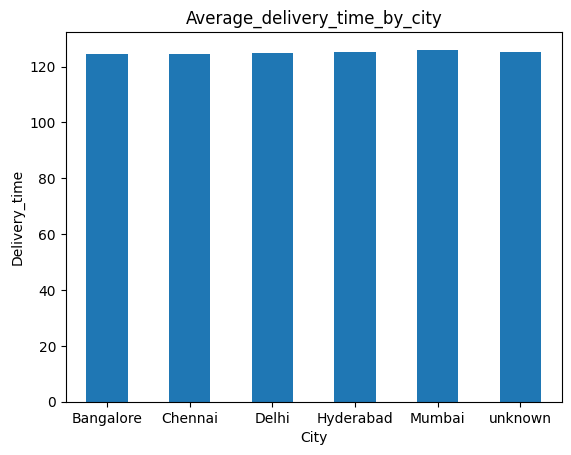

In [ ]:
avg_time.plot(kind="bar")
plt.title("Average_delivery_time_by_city")
plt.xlabel("City")
plt.ylabel("Delivery_time")
plt.xticks(rotation = 0)
plt.show()

insights:
Average delivery time is very similar across cities, around 124–126 minutes. Mumbai has the highest average at 126.04 minutes

8.  Distance vs delivery delay analysis

In [ ]:
delivery_delay = df.groupby("Distance_km")["Delivery_Time_Min"].mean()
delivery_delay

,Delivery_Time_Min
Distance_km,
1.00,126.541667
1.01,135.500000
1.02,99.457143
1.03,125.043478
1.04,137.911765
...,...
39.96,108.666667
39.97,108.090909
39.98,166.083333


In [ ]:
def group_distance(x):
  if x <= 5:
    return "1-5"
  elif x <= 10:
    return "6-10"
  elif x <= 15:
    return "11-15"
  elif x <= 20:
    return "16-20"
  elif x <= 25:
    return "21-25"
  elif x <= 30:
    return "26-30"
  elif x <= 35:
    return "31-35"
  elif x <= 40:
    return "36-40"

df["Distance_Group"] = df["Distance_km"].apply(group_distance)
delay = df.groupby("Distance_Group")["Delivery_Time_Min"].mean()


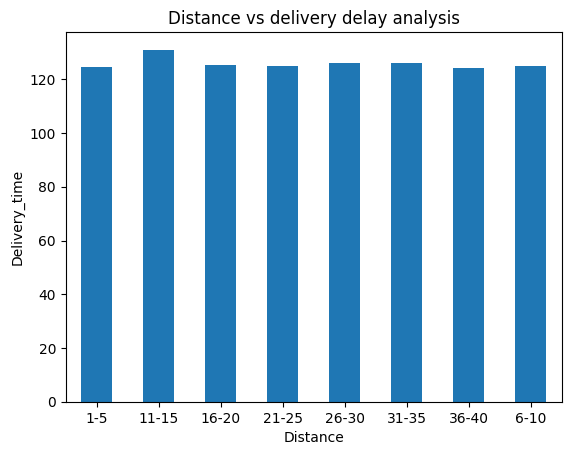

In [ ]:
delay.plot(kind="bar")
plt.title("Distance vs delivery delay analysis",)
plt.xlabel("Distance")
plt.ylabel("Delivery_time")
plt.xticks(rotation =0)
plt.show()

Insights : Thre is no correlation between distance and delivery_time

9. Delivery rating vs delivery time




In [ ]:
df["Delivery_Time_Min"].max()

300.0

In [ ]:
def group_min(x):
  if x <= 60:
     return "1-60"
  elif x <= 120:
     return "61-120"
  elif x <= 180:
     return "121-180"
  elif x <= 240:
    return "181-240"
  else:
     return "241-300"
df["group_delivery_time"] = df["Delivery_Time_Min"].apply(group_min)
rating_delivery_time = df.groupby("group_delivery_time")["Delivery_Rating"].mean()
rating_delivery_time

,Delivery_Rating
group_delivery_time,
1-60,2.825605
121-180,2.820341
181-240,2.843557
241-300,2.834704
61-120,2.823809


Text(0, 0.5, 'Delivery_rating')

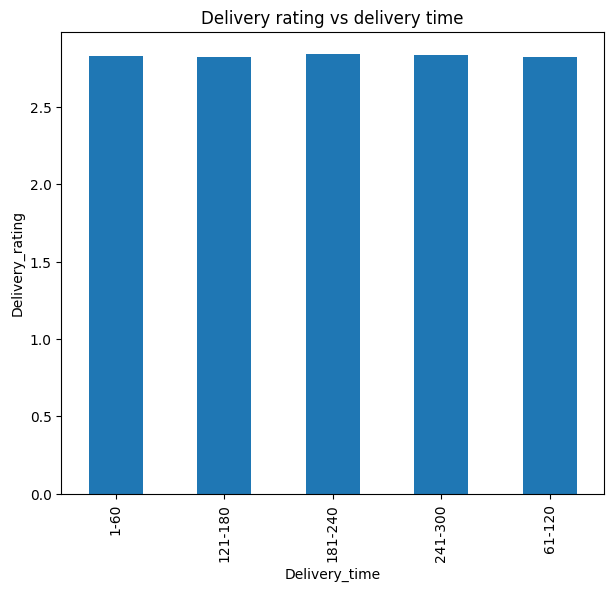

In [ ]:
plt.figure(figsize=(7,6))
rating_delivery_time.plot(kind="bar")
plt.title("Delivery rating vs delivery time")
plt.xlabel("Delivery_time")
plt.ylabel("Delivery_rating")

Text(0, 0.5, 'Delivery_rating')

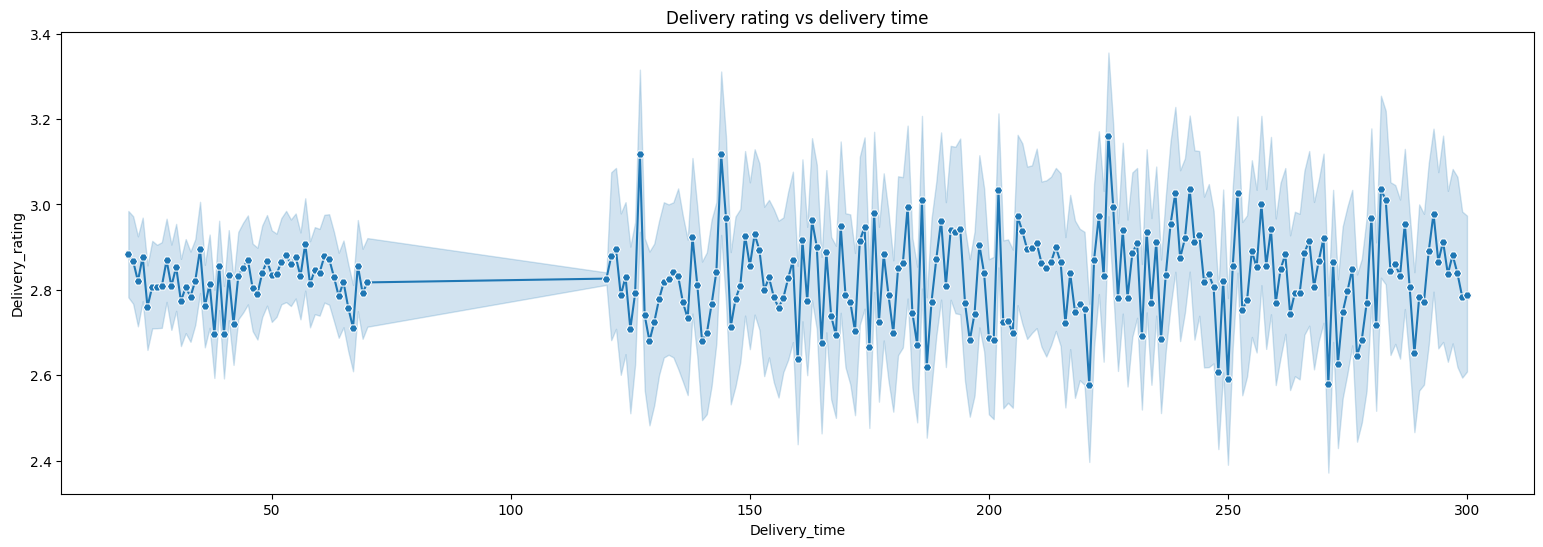

In [ ]:
plt.figure(figsize=(19,6))
sns.lineplot(data = df, x= "Delivery_Time_Min", y = "Delivery_Rating",marker ="H")
plt.title("Delivery rating vs delivery time")
plt.xlabel("Delivery_time")
plt.ylabel("Delivery_rating")

insights :Delivery ratings are quite similar across delivery-time groups

10. . Top-rated restaurants


In [ ]:
top_restarunt = df.groupby("Restaurant_Name")["Restaurant_Rating"].mean().sort_values(ascending=False).head(10)
top_restarunt

,Restaurant_Rating
Restaurant_Name,
Restaurant_101,4.329944
Restaurant_162,4.317222
Restaurant_1,4.311458
Restaurant_496,4.302985
Restaurant_481,4.301587
Restaurant_209,4.300478
Restaurant_352,4.300000
Restaurant_355,4.298324
Restaurant_403,4.297268


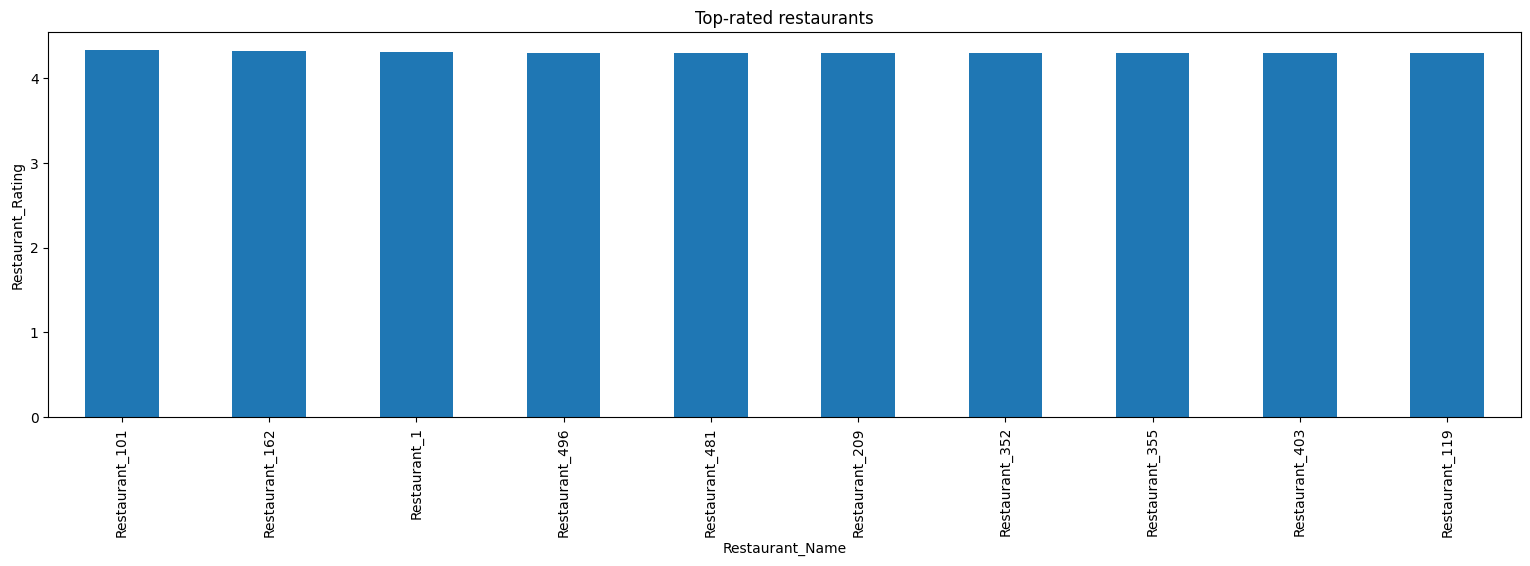

In [ ]:
plt.figure(figsize=(19,5))
top_restarunt.plot(kind="bar")
plt.title("Top-rated restaurants")
plt.xlabel("Restaurant_Name")
plt.ylabel("Restaurant_Rating")
plt.show()

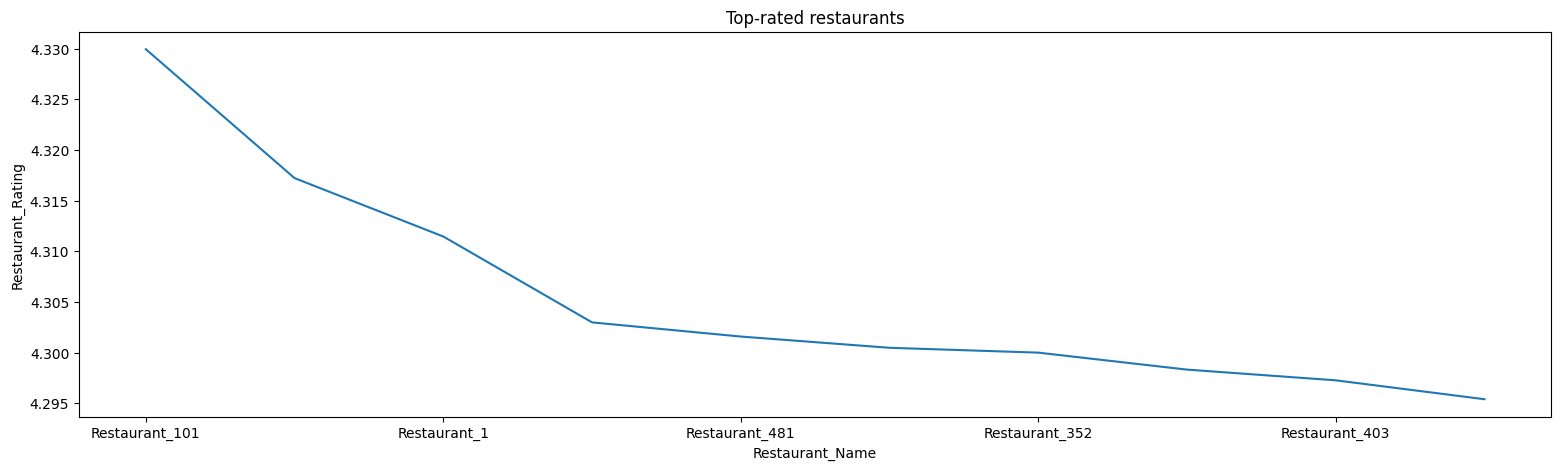

In [ ]:
plt.figure(figsize=(19,5))
top_restarunt.plot(kind="line")
plt.title("Top-rated restaurants")
plt.xlabel("Restaurant_Name")
plt.ylabel("Restaurant_Rating")
plt.show()

insighst : Restaurant_101 has the highest average restaurant rating at about 4.33/5.

11. Cancellation rate by restaurant

In [ ]:
cancel_rate = (
    df.groupby("Restaurant_Name")["Cancellation_Reason"]
      .apply(lambda x: (x != "Not_Applicable").mean() * 100)
      .reset_index(name="Cancellation_Rate")
)

In [ ]:
cancel_rate = ( df.groupby("Restaurant_Name")["Cancellation_Reason"].apply(lambda x : (x != "Not_Applicable").mean()*100).reset_index(name="Cancellation_Rate")).sort_values(by = "Cancellation_Rate",ascending=False).head(10)

In [ ]:
cancel_rate

,Restaurant_Name,Cancellation_Rate
436,Restaurant_492,15.104167
5,Restaurant_103,14.347826
445,Restaurant_50,13.917526
108,Restaurant_197,13.903743
395,Restaurant_455,13.888889
405,Restaurant_464,13.888889
210,Restaurant_289,13.875598
16,Restaurant_113,13.793103
363,Restaurant_426,13.744076
260,Restaurant_333,13.725490


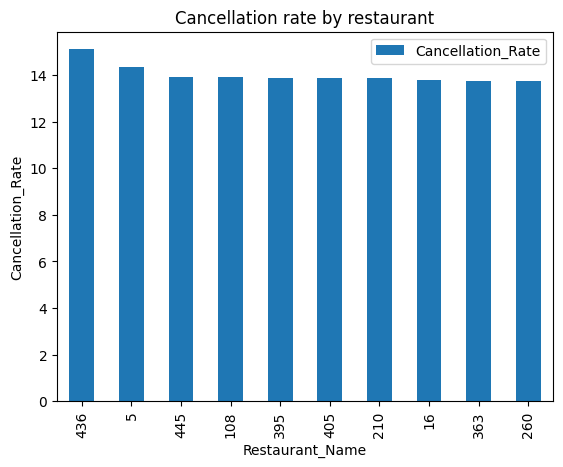

In [ ]:
cancel_rate.plot(kind="bar")
plt.title("Cancellation rate by restaurant")
plt.xlabel("Restaurant_Name")
plt.ylabel("Cancellation_Rate")
plt.show()


insights : Restaurant_492 has the highest cancellation rate among the restaurants analyzed, at about 15.10%.

12. Cuisine-wise performance

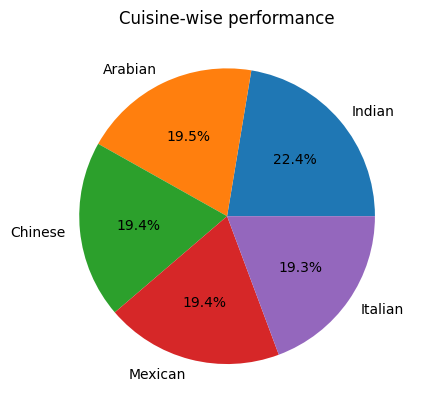

In [ ]:
plt.pie(df["Cuisine_Type"].value_counts(),labels = df["Cuisine_Type"].value_counts().index,autopct="%1.1f%%")
plt.title("Cuisine-wise performance")
plt.show()

Insights : Indian cuisine performed the best in terms of revenue.

13. Peak hour demand analysis

In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_performance_category,Age_Group,Price_Reduction,Distance_Group,group_delivery_time
0,ORD000001,CUST6948,19.0,Male,unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,1197.0,100.0,1097.0,UPI,Delivered,Not_Applicable,DP563,5.0,4.4,Weekend,True,0.13,slow,Younger_Adult,100.0,16-20,181-240
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,Not_Applicable,DP369,5.0,4.7,Weekday,True,0.48,Fast,Adult,20.0,26-30,1-60
2,ORD000003,CUST1765,39.0,Male,Delhi,unknown,RES723,Restaurant_244,Arabian,2024-12-08,207.0,9.97,757.0,20.0,737.0,Wallet,Delivered,Not_Applicable,DP580,4.0,4.9,Weekend,True,0.08,slow,Adult,20.0,6-10,181-240
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,1197.0,100.0,1097.0,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,False,0.04,neutral,Adult,100.0,16-20,121-180
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.0,20.0,352.0,Card,Delivered,Not_Applicable,DP728,2.0,4.4,Weekend,False,0.12,Fast,Senior,20.0,6-10,1-60


In [ ]:
df["Peak_Hour"]

,Peak_Hour
0,True
1,True
2,True
3,False
4,False
...,...
98981,False
98982,True
98983,False
98984,True


In [ ]:
peak_demand = df.groupby("Peak_Hour").size()
peak_demand

,0
Peak_Hour,
False,65845
True,33141


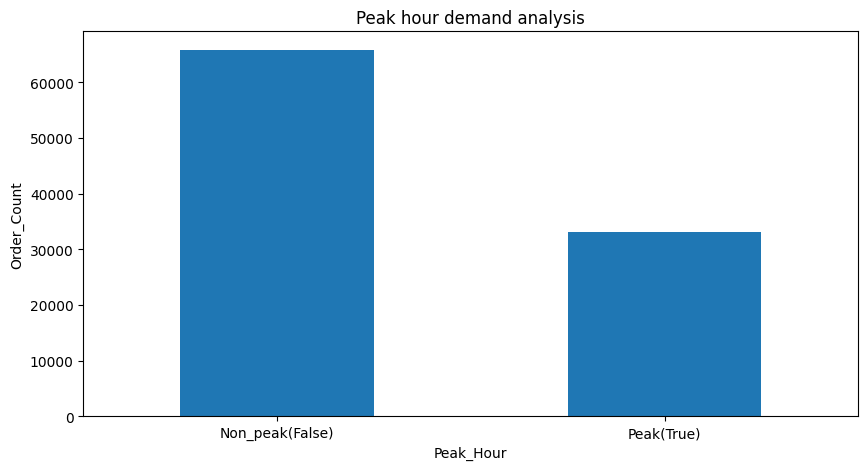

In [ ]:
plt.figure(figsize=(10,5))
peak_demand.plot(kind="bar")
plt.title("Peak hour demand analysis")
plt.xlabel("Peak_Hour")
plt.ylabel("Order_Count")
plt.xticks(ticks=[0,1],labels = [ "Non_peak(False)","Peak(True)"],rotation = 0)
plt.show()

insights : : Non-peak hours have higher order than peak hours.

14. Payment mode preferences

In [ ]:
df["Payment_Mode"].value_counts()

,count
Payment_Mode,
Card,39603
Wallet,19885
COD,19767
UPI,19731


In [ ]:
order_preferences = df.groupby("Payment_Mode")["Order_Value"].sum()

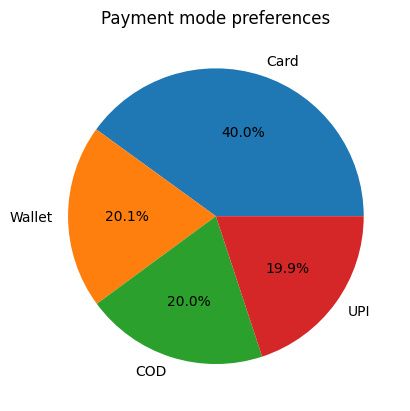

In [ ]:
plt.pie(df["Payment_Mode"].value_counts(),labels = df["Payment_Mode"].value_counts().index,autopct="%1.1f%%")
plt.title("Payment mode preferences")
plt.show()

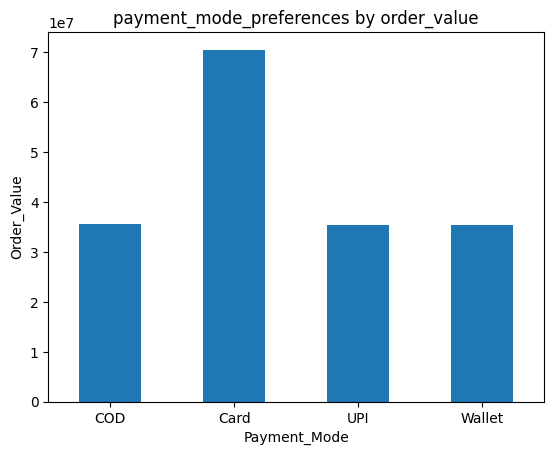

In [ ]:
order_preferences.plot(kind="bar")
plt.title("payment_mode_preferences by order_value")
plt.xlabel("Payment_Mode")
plt.ylabel("Order_Value")
plt.xticks(rotation = 0)
plt.show()

insights : Card is the most-used payment method with 39,603 orders, followed by Wallet, COD and UPI.

15. Cancellation reason analysis

In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_performance_category,Age_Group,Price_Reduction,Distance_Group,group_delivery_time
0,ORD000001,CUST6948,19.0,Male,unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,187.0,15.75,1197.0,100.0,1097.0,UPI,Delivered,Not_Applicable,DP563,5.0,4.4,Weekend,True,0.13,slow,Younger_Adult,100.0,16-20,181-240
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,Not_Applicable,DP369,5.0,4.7,Weekday,True,0.48,Fast,Adult,20.0,26-30,1-60
2,ORD000003,CUST1765,39.0,Male,Delhi,unknown,RES723,Restaurant_244,Arabian,2024-12-08,207.0,9.97,757.0,20.0,737.0,Wallet,Delivered,Not_Applicable,DP580,4.0,4.9,Weekend,True,0.08,slow,Adult,20.0,6-10,181-240
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,143.0,15.68,1197.0,100.0,1097.0,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,False,0.04,neutral,Adult,100.0,16-20,121-180
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,51.0,9.60,372.0,20.0,352.0,Card,Delivered,Not_Applicable,DP728,2.0,4.4,Weekend,False,0.12,Fast,Senior,20.0,6-10,1-60


In [ ]:
cancel_reason =df["Cancellation_Reason"].apply(lambda x: x if x != "Not_Applicable" else None).value_counts()

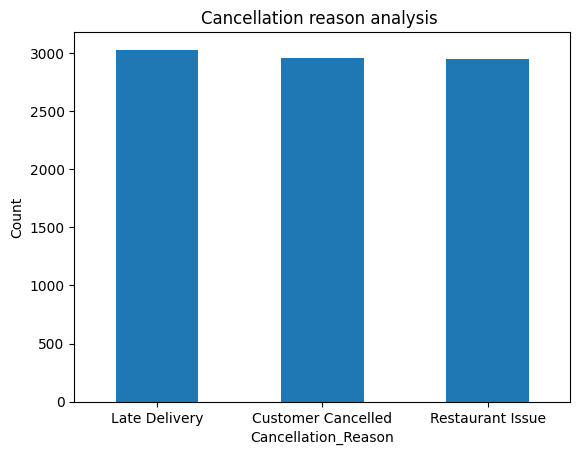

In [ ]:
cancel_reason.plot(kind="bar")
plt.xlabel("Cancellation_Reason")
plt.ylabel("Count")
plt.title("Cancellation reason analysis ")
plt.xticks(rotation = 0)
plt.show()



Insights : The main cancellation categories are Late Delivery (3,032), Customer Cancelled (2,963) and Restaurant Issue (2,949).



## Overal insights:
“From my analysis, I found that adults generate the highest revenue, weekdays have more orders than weekends, and Bangalore has the highest city revenue. Indian cuisine generates the highest revenue. I also found that Restaurant_492 has the highest cancellation rate, while Restaurant_101 has the highest average rating. Card is the most preferred payment method, and late delivery is the most common cancellation reason.”